# Shared prior samples across forward models

Montage of four shared prior realizations $w \sim N(0, C)$ (top row) and the corresponding $(m, u=F(m))$ for Poisson, linear elasticity, and hyperelasticity in the rows below. Each **column** is one sample; read downward to follow a single $w$ through all three models.

Samples are **computed here** (not loaded from saved `.npz` files): one `PriorSampler` draws $w$; each model applies its own $(\alpha_m, \beta_m)$ map and forward operator $F$, matching the loops in the individual problem notebooks.

<p align="center"> <img src="elas_model_samples.png" width="600"> </p>

In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from dolfinx import mesh
from dolfinx.fem import functionspace
from dolfinx.mesh import CellType
from mpi4py import MPI

NOTEBOOK_DIR = os.getcwd()
ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "..", ".."))
SURVEY_WORK = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", ".."))

for path in [
    os.path.join(ROOT, "src/plotting"),
    os.path.join(ROOT, "src/prior"),
    os.path.join(ROOT, "src/pde"),
    os.path.join(SURVEY_WORK, "problems/poisson"),
    os.path.join(SURVEY_WORK, "problems/linear_elasticity"),
    os.path.join(SURVEY_WORK, "problems/hyperelasticity"),
]:
    sys.path.insert(0, path)

from plot_mix_collection import get_default_plot_mix_collection_data, plot_mix_collection
from priorSampler import PriorSampler
from poissonModel import PoissonModel
from linearElasticityModel import LinearElasticityModel
from hyperelasticityModel import HyperelasticityModel

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

In [6]:
seed = 0
np.random.seed(seed)

N_SAMPLES = 4
N_ROWS = 5   # w + (m, u) for each of 3 models
N_COLS = N_SAMPLES

# Shared prior (same in LinearElasticity / Hyperelasticity notebooks)
prior_ac = 0.005
prior_cc = 0.2
nx, ny = 50, 50
fe_order = 1

POISSON_PARAMS = {"logn_scale": 1.0, "logn_translate": 0.0}
LE_PARAMS = {"logn_scale": 100.0, "logn_translate": 1000.0}
HE_PARAMS = {"logn_scale": 100.0, "logn_translate": 1000.0}

OUTPUT_PNG = os.path.join(NOTEBOOK_DIR, "elas_model_samples.png")

M_FORMULA = r"$m = \alpha_m\, \exp(w) + \beta_m$"
U_FORMULA = r"$u = F(m)$"
M_FORMULA_ONE_LINE = r"$m$"
U_FORMULA_ONE_LINE = r"$u$"
W_TITLE = r"$w \sim N(0, C)$"
SUP_TITLE = (
    r"Samples $w \sim N(0, C)$ and corresponding $m = \alpha_m\, \exp(w) + \beta_m$ and $u = F(m)$"
)

In [7]:
domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, cell_type=CellType.triangle)
Vm = functionspace(domain, ("Lagrange", fe_order))
Vu_poisson = Vm
Vu_vector = functionspace(domain, ("Lagrange", fe_order, (2,)))

prior_sampler = PriorSampler(Vm, prior_ac, prior_cc, seed)

models = {
    "Poisson": PoissonModel(
        Vm, Vu_poisson, prior_sampler,
        POISSON_PARAMS["logn_scale"], POISSON_PARAMS["logn_translate"], seed,
    ),
    "Linear Elasticity": LinearElasticityModel(
        Vm, Vu_vector, prior_sampler,
        LE_PARAMS["logn_scale"], LE_PARAMS["logn_translate"], seed,
    ),
    "Hyperelasticity": HyperelasticityModel(
        Vm, Vu_vector, prior_sampler,
        HE_PARAMS["logn_scale"], HE_PARAMS["logn_translate"], seed,
    ),
}

nodes = models["Poisson"].m_nodes
print(
    f"mesh nodes={nodes.shape[0]}, "
    f"Poisson u_dim={models['Poisson'].u_dim}, "
    f"LE u_dim={models['Linear Elasticity'].u_dim}, "
    f"HE u_dim={models['Hyperelasticity'].u_dim}"
)

mesh nodes=2601, Poisson u_dim=2601, LE u_dim=5202, HE u_dim=5202


In [8]:
def draw_w_samples(n_samples: int) -> list[np.ndarray]:
    """Draw w ~ N(0,C) using the same sequential protocol as the problem notebooks."""
    w_buf = prior_sampler.empty_sample()
    w_list = []
    for i in range(n_samples):
        t0 = time.perf_counter()
        # if i == 0:
        #     w_buf = prior_sampler.mean.copy()
        # else:
        #     w_buf = prior_sampler(w_buf)[0]
        w_buf = prior_sampler(w_buf)[0]
        w_list.append(w_buf.copy())
        print(f"  w sample {i:2d} drawn in {time.perf_counter() - t0:.3f} s")
    return w_list


def forward_models(w: np.ndarray) -> dict[str, dict[str, np.ndarray]]:
    """Apply each model's alpha/beta map and forward operator to the same w."""
    out = {}
    for name, model in models.items():
        t0 = time.perf_counter()
        m = model.empty_m()
        u = model.empty_u()
        m = model.transform_gaussian_pointwise(w, m)
        u = model.solveFwd(u, m, transform_m=False)
        out[name] = {"m": m, "u": u}
        print(f"  {name:18s} forward in {time.perf_counter() - t0:.3f} s")
    return out


print("Drawing shared w samples...")
w_samples = draw_w_samples(N_SAMPLES)

computed = []
for i, w in enumerate(w_samples):
    print(f"Forward solves for row {i}...")
    computed.append(forward_models(w))

Drawing shared w samples...
  w sample  0 drawn in 0.000 s
  w sample  1 drawn in 0.000 s
  w sample  2 drawn in 0.000 s
  w sample  3 drawn in 0.000 s
Forward solves for row 0...
  Poisson            forward in 0.004 s
  Linear Elasticity  forward in 0.012 s
  Hyperelasticity    forward in 0.627 s
Forward solves for row 1...
  Poisson            forward in 0.004 s
  Linear Elasticity  forward in 0.011 s
  Hyperelasticity    forward in 0.605 s
Forward solves for row 2...
  Poisson            forward in 0.003 s
  Linear Elasticity  forward in 0.011 s
  Hyperelasticity    forward in 0.606 s
Forward solves for row 3...
  Poisson            forward in 0.003 s
  Linear Elasticity  forward in 0.011 s
  Hyperelasticity    forward in 0.605 s


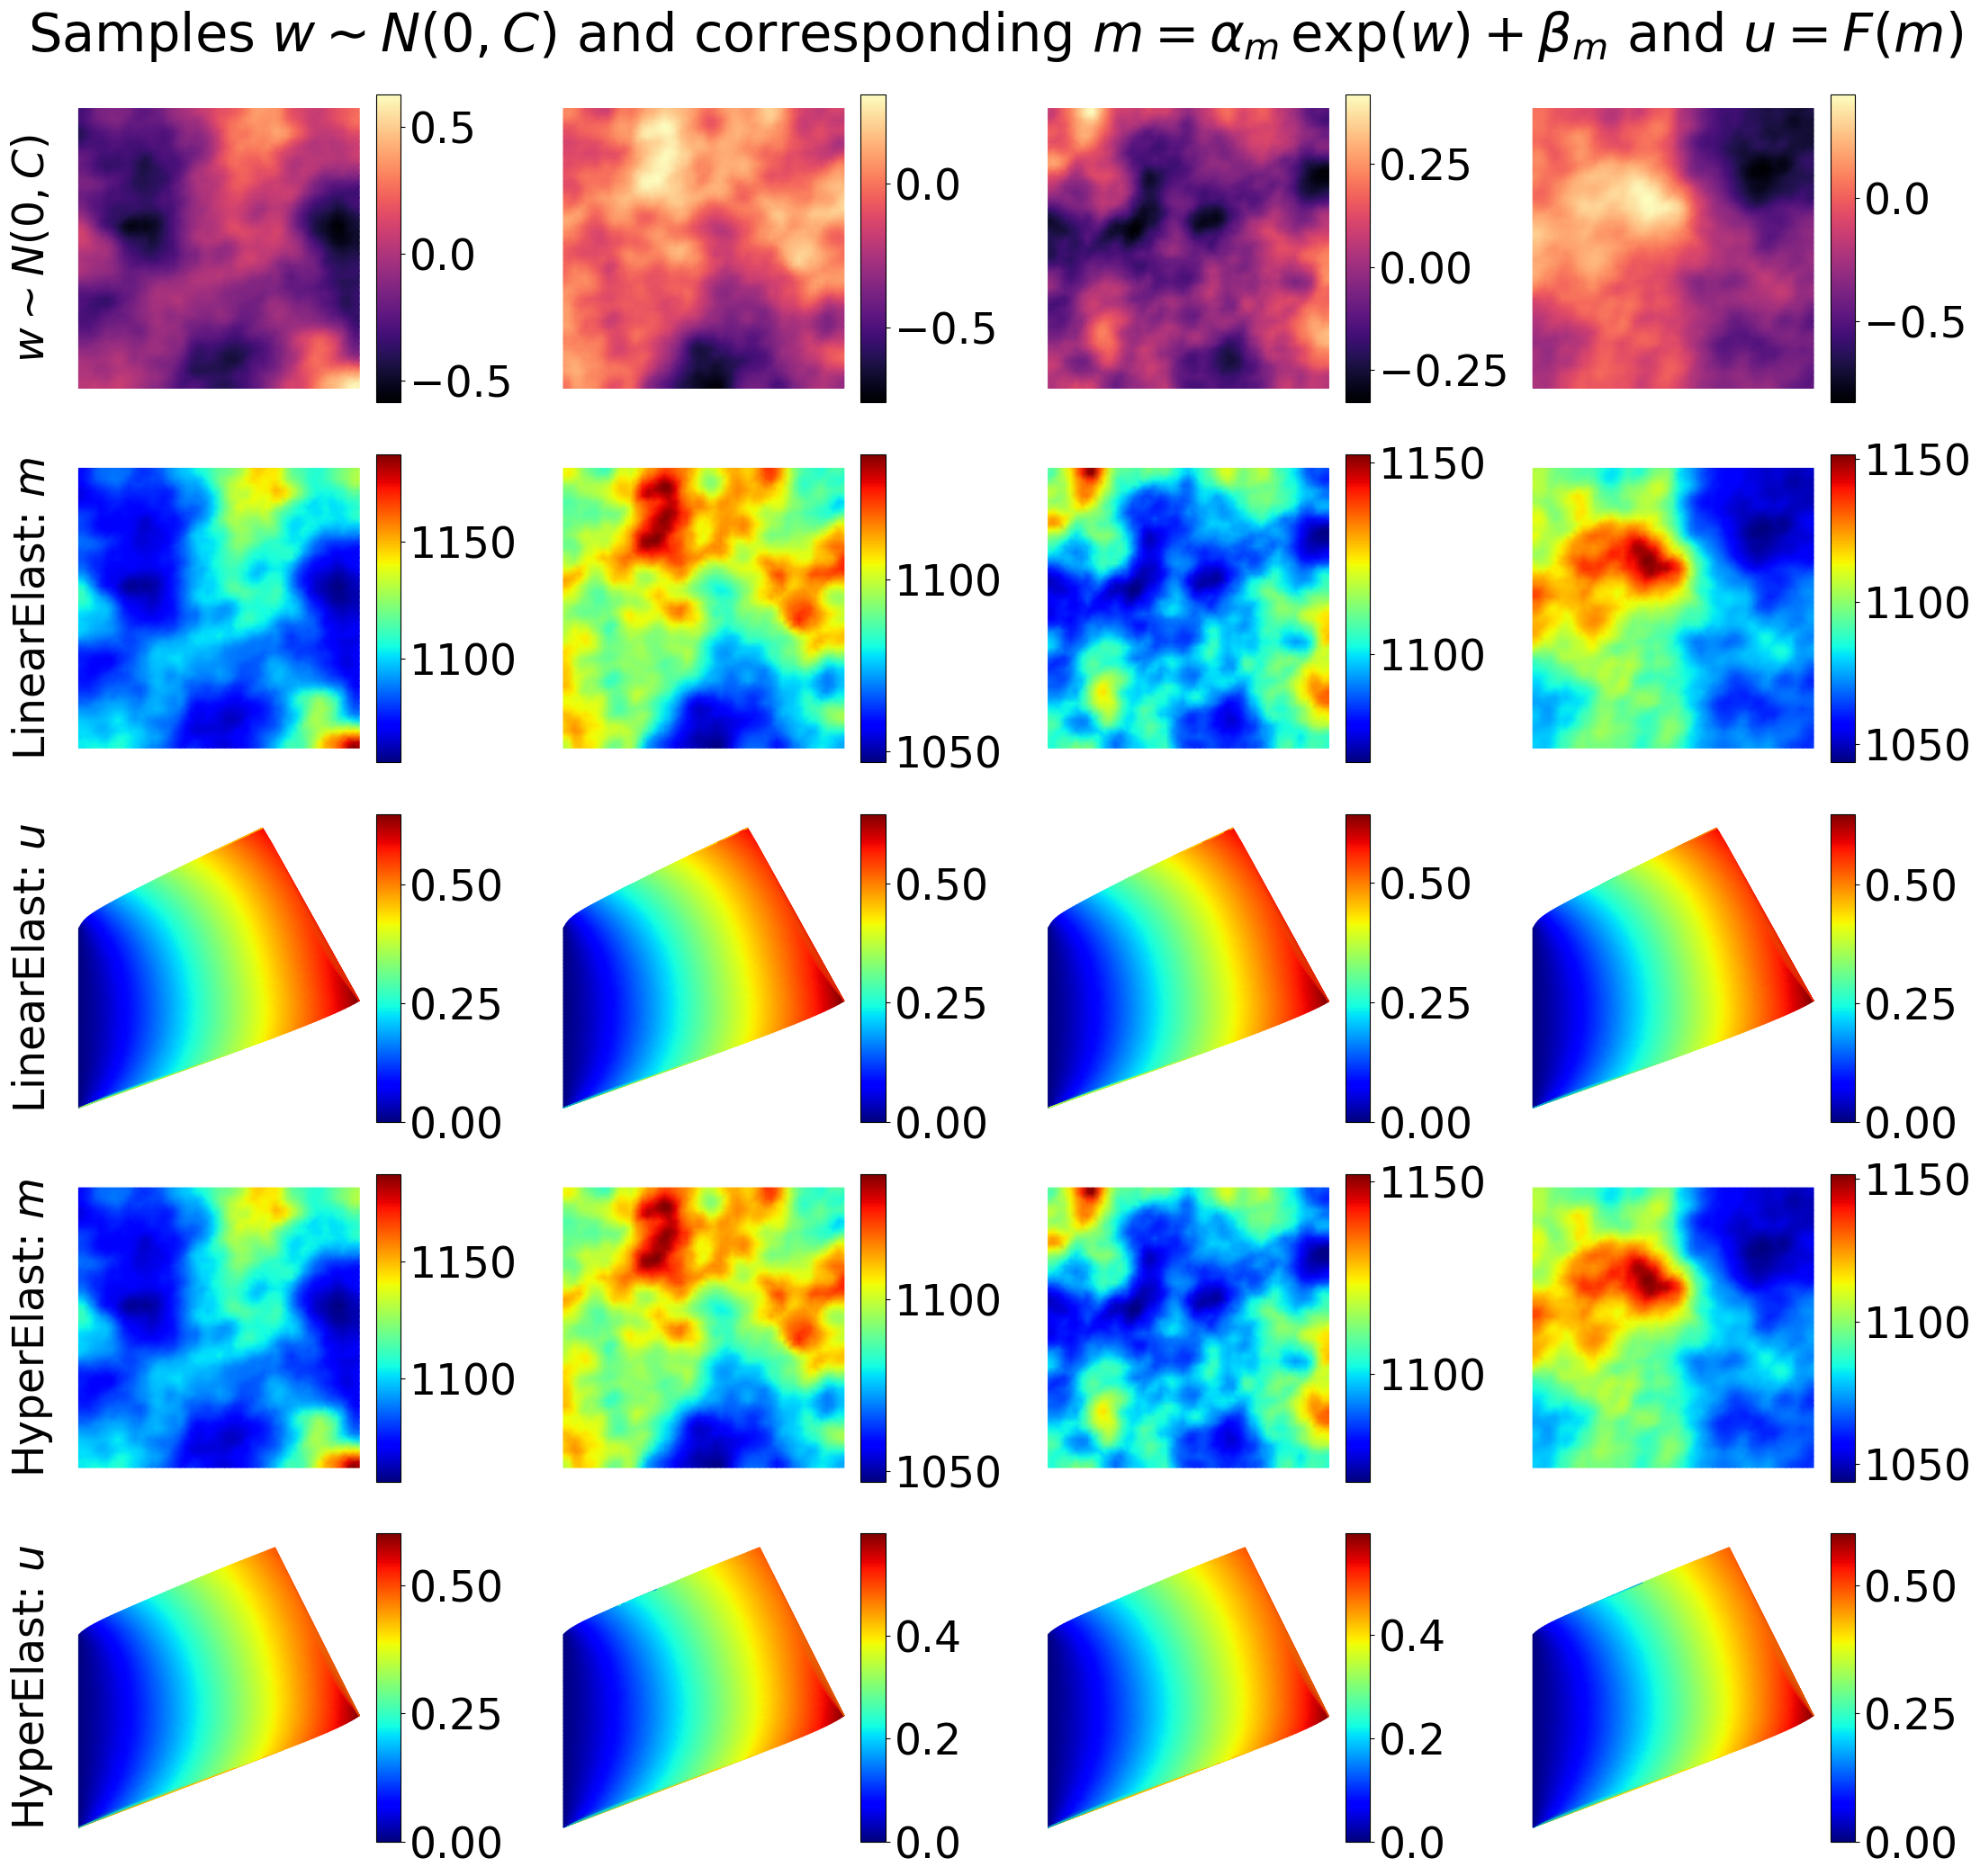

Saved /Users/prashant/Dropbox/Work/Simulations/neuralnet_works/error_corrector_direction/neural_operators/survey_work/common/all_model_samples/elas_model_samples.png


In [12]:
def two_line_title(model_name: str, formula: str) -> str:
    return f"{model_name}\n{formula}"

def one_line_title(model_name: str, formula: str) -> str:
    return f"{model_name}: {formula}"


# Row order: shared w, then (m, u) per model.
ROW_SPECS = [
    {"label": W_TITLE, "cmap": "magma", "is_vec": False, "add_disp": False,
     "field": lambda d: d["w"]},
    {"label": one_line_title("LinearElast", M_FORMULA_ONE_LINE), "cmap": "jet", "is_vec": False, "add_disp": False,
     "field": lambda d: d["Linear Elasticity"]["m"]},
    {"label": one_line_title("LinearElast", U_FORMULA_ONE_LINE), "cmap": "jet", "is_vec": True, "add_disp": True,
     "field": lambda d: d["Linear Elasticity"]["u"]},
    {"label": one_line_title("HyperElast", M_FORMULA_ONE_LINE), "cmap": "jet", "is_vec": False, "add_disp": False,
     "field": lambda d: d["Hyperelasticity"]["m"]},
    {"label": one_line_title("HyperElast", U_FORMULA_ONE_LINE), "cmap": "jet", "is_vec": True, "add_disp": True,
     "field": lambda d: d["Hyperelasticity"]["u"]},
]


def build_montage(sample_data: list[dict[str, dict[str, np.ndarray]]]) -> None:
    u_vec = []
    cmapvec = []
    flag_is_vec = []
    flag_add_disp = []
    plot_type = []

    for spec in ROW_SPECS:
        row_fields = []
        for sample_idx in range(N_SAMPLES):
            payload = {"w": w_samples[sample_idx], **sample_data[sample_idx]}
            row_fields.append(spec["field"](payload))
        u_vec.append(row_fields)
        cmapvec.append([spec["cmap"]] * N_COLS)
        flag_is_vec.append([spec["is_vec"]] * N_COLS)
        flag_add_disp.append([spec["add_disp"]] * N_COLS)
        plot_type.append(["field"] * N_COLS)

    plot_data = get_default_plot_mix_collection_data(
        rows=N_ROWS,
        cols=N_COLS,
        nodes=nodes,
        figsize=(22, 20),
        fs=34,
        sup_title=SUP_TITLE,
        y_sup_title=1.04,
        savefilename=OUTPUT_PNG,
        u=u_vec,
        cmap=cmapvec,
        title=[[None] * N_COLS for _ in range(N_ROWS)],
        row_titles=[spec["label"] for spec in ROW_SPECS],
        row_title_pad=0.03,
        is_vec=flag_is_vec,
        add_disp=flag_add_disp,
        plot_type=plot_type,
    )
    plot_mix_collection(plot_data)


build_montage(computed)
print(f"Saved {OUTPUT_PNG}")